In [1]:
from google.colab import files
uploaded = files.upload()



Saving dataset_Implementation-2.zip to dataset_Implementation-2.zip


In [2]:
import zipfile

zip_ref = zipfile.ZipFile("dataset_Implementation-2.zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
train_path = "/content/dataset_Implementation-2/Train"
val_path = "/content/dataset_Implementation-2/Validation"
test_path = "/content/dataset_Implementation-2/Test"

In [5]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

In [6]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

validation_data = val_gen.flow_from_directory(
    val_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 4462 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 1680 images belonging to 2 classes.


In [7]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [12]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 34s 201ms/step - accuracy: 0.8615 - loss: 0.3455 - val_accuracy: 0.8811 - val_loss: 0.2508
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.8743 - loss: 0.2975 - val_accuracy: 0.8922 - val_loss: 0.2362
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.8799 - loss: 0.3005 - val_accuracy: 0.8878 - val_loss: 0.2528
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 162ms/step - accuracy: 0.8779 - loss: 0.2810 - val_accuracy: 0.9089 - val_loss: 0.2214
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 170ms/step - accuracy: 0.8853 - loss: 0.2613 - val_accuracy: 0.9122 - val_loss: 0.2072
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 171ms/step - accuracy: 0.8918 - loss: 0.2582 - val_accuracy: 0.9100 - val_loss: 0.2129
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - accuracy: 0.8987 - loss: 0.2447 - val_accuracy: 0.9056 - val_loss: 0.2340
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 171ms/step - accuracy: 0.9000 - loss: 0

In [13]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9530 - loss: 0.1412
Test Accuracy: 0.9529761672019958


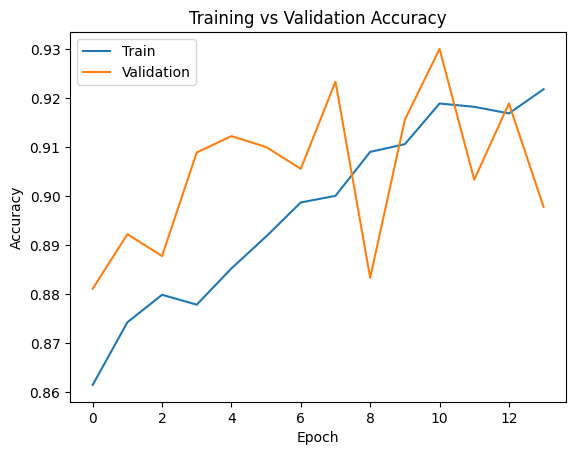

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [15]:
predictions = model.predict(test_data)

predicted_classes = np.round(predictions)

cm = confusion_matrix(test_data.classes, predicted_classes)

print(cm)

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
[[ 112   26]
 [  53 1489]]


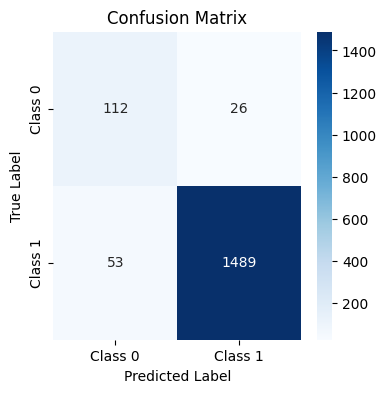

In [19]:
import seaborn as sns
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
print(classification_report(
    test_data.classes,
    predicted_classes
))

              precision    recall  f1-score   support

           0       0.68      0.81      0.74       138
           1       0.98      0.97      0.97      1542

    accuracy                           0.95      1680
   macro avg       0.83      0.89      0.86      1680
weighted avg       0.96      0.95      0.95      1680



In [21]:
model.save("waste_classification_model_v2.h5")

In [22]:
files.download("waste_classification_model_v2.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
from google.colab import files

print("="*50)
print("UPLOAD YOUR MODEL FILE")
print("="*50)
print("Please select 'waste_classification_model_v2.h5' from your computer")

# This opens a file picker
uploaded = files.upload()

# Verify upload
import os
print("\n✅ Uploaded files:")
for filename in uploaded.keys():
    print(f"  - {filename} ({os.path.getsize(filename)} bytes)")

# Check for .h5 files
h5_files = [f for f in os.listdir() if f.endswith('.h5')]
print(f"\n📁 .h5 files in Colab: {h5_files}")

UPLOAD YOUR MODEL FILE
Please select 'waste_classification_model_v2.h5' from your computer


Saving waste_classification_model_v2.h5 to waste_classification_model_v2.h5

✅ Uploaded files:
  - waste_classification_model_v2.h5 (39704352 bytes)

📁 .h5 files in Colab: ['waste_classification_model_v2.h5']


In [3]:
import os
from tensorflow.keras.models import load_model

# Check if model is there
print("Files in current directory:")
for f in os.listdir():
    if f.endswith('.h5'):
        print(f"  ✅ {f}")

# Load the model
model = load_model('waste_classification_model_v2.h5')
print("\n✅ Model loaded successfully!")
print(f"📊 Model type: {type(model)}")

Files in current directory:
  ✅ waste_classification_model_v2.h5



✅ Model loaded successfully!
📊 Model type: <class 'keras.src.models.sequential.Sequential'>


In [4]:
import zipfile
import os
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload ZIP file
print("📦 Upload a ZIP folder containing waste images")
print("   (The ZIP should contain .jpg, .jpeg, or .png files)")
print("-" * 50)

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {zip_file}")

# Extract
extract_path = '/content/extracted_images'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"📂 Extracted to: {extract_path}")

# Find images
image_extensions = ('.jpg', '.jpeg', '.png')
image_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_files.append(os.path.join(root, file))

print(f"\n📸 Found {len(image_files)} images\n")

# Calculate grid size (5 images per row)
num_images = len(image_files)
num_cols = 3
num_rows = (num_images + num_cols - 1) // num_cols  # Ceiling division

# Create figure with appropriate size
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
# Flatten axes for easy indexing (if multiple rows/cols)
if num_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if num_cols == 1 else axes

# Store results for summary
results = []

# Predict and display each image
for idx, img_path in enumerate(image_files):
    try:
        # Load and preprocess
        img = image.load_img(img_path, target_size=(128, 128))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Predict
        prediction = model.predict(img_array, verbose=0)[0][0]

        # Determine result
        if prediction >= 0.5:
            result = "RECYCLABLE"
            confidence = prediction * 100
            color = 'green'
        else:
            result = "ORGANIC"
            confidence = (1 - prediction) * 100
            color = 'red'

        # Store result
        results.append({
            'file': os.path.basename(img_path),
            'result': result,
            'confidence': confidence
        })

        # Display image in subplot
        img_display = image.load_img(img_path)
        axes[idx].imshow(img_display)
        axes[idx].set_title(f"{result}\n({confidence:.1f}%)",
                            fontsize=10, color=color, fontweight='bold')
        axes[idx].axis('off')

    except Exception as e:
        print(f"⚠️ Error processing {img_path}: {e}")

# Hide any unused subplots
for idx in range(len(image_files), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*60)
print("PREDICTION SUMMARY")
print("="*60)
print(f"{'Image Name':<35} {'Prediction':<15} {'Confidence':<10}")
print("-"*60)

for r in results:
    print(f"{r['file']:<35} {r['result']:<15} {r['confidence']:.1f}%")

print("-"*60)

# Count statistics
recyclable_count = sum(1 for r in results if r['result'] == 'RECYCLABLE')
organic_count = sum(1 for r in results if r['result'] == 'ORGANIC')

print(f"\n📊 STATISTICS:")
print(f"   ♻️ Recyclable: {recyclable_count} images")
print(f"   🍃 Organic: {organic_count} images")
print(f"   📸 Total: {len(results)} images")
print("="*60)

Output hidden; open in https://colab.research.google.com to view.